# The Monte Carlo Permutation Method MCPM

## Objectif pédagogique

Ce notebook transforme la **Monte Carlo Permutation Method**, ou **MCPM**, en outil concret pour la recherche de stratégies de trading.

L'idée centrale est simple :

> La MCPM demande : “Le meilleur backtest de mon univers de règles est-il vraiment supérieur au meilleur résultat que le hasard peut produire après mélange des rendements du marché ?”

Dans un processus de recherche intensif, on ne teste pas une seule règle.

On teste souvent 10, 100, 1 000, voire davantage de variantes.

Le danger est alors le **data-mining bias** : plus on teste de règles, plus on augmente mécaniquement la probabilité qu'une règle ait l'air excellente par pur hasard.

La MCPM construit donc une **distribution du maximum généré par le bruit**.

## Intuition

Supposons que tu aies :

- une série de **rendements de marché** ;
- un univers de $N$ règles ;
- pour chaque règle, une série de signaux $+1$, $0$ ou $-1$.

Le rendement d'une règle est :

$$
r_{i,t}^{\text{rule}} = s_{i,t-1} \times r_t^{\text{market}}
$$

où :

- $s_{i,t-1}$ est le signal de la règle $i$ connu avant le rendement ;
- $r_t^{\text{market}}$ est le rendement du marché au temps $t$.

La MCPM détruit le lien temporel entre les signaux et les rendements en mélangeant les rendements du marché :

$$
r_{\pi(t)}^{\text{market}}
$$

Puis elle recalcule la performance de toutes les règles sur ce marché mélangé.

Pour chaque permutation, elle conserve uniquement :

$$
\max_{i=1,\dots,N} \bar{r}_i^{\text{permuté}}
$$

Ce maximum représente le **meilleur champion du bruit**.

## MCPM vs bootstrap classique vs White's Reality Check

| Méthode | Ce qui est randomisé | Objectif | Corrige les comparaisons multiples ? |
|---|---:|---:|---:|
| **Bootstrap classique** | Rendements rééchantillonnés avec remise | Incertitude d'une règle | Non, sauf adaptation |
| **WRC** | Rendements des règles | Tester le meilleur candidat après minage | Oui |
| **MCPM** | Rendements du marché permutés sans remise | Tester si les signaux ont un vrai lien avec les rendements | Oui |

La différence importante est que la MCPM ne rééchantillonne pas avec remise.

Elle **mélange les rendements réels du marché**.

Cela conserve exactement la distribution empirique des rendements, mais détruit leur alignement temporel avec les signaux.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Générer un marché synthétique

On va créer une série de rendements journaliers.

Dans cet exemple, le marché n'a presque pas de drift.

Le but n'est pas de modéliser parfaitement un actif réel, mais de créer un terrain pédagogique où l'on peut observer le danger du **minage de données**.

In [2]:
n_days = 1_000

market_returns = np.random.normal(
    loc=0.0001,
    scale=0.01,
    size=n_days
)

dates = pd.date_range("2020-01-01", periods=n_days, freq="B")

market = pd.Series(market_returns, index=dates, name="market_return")

price = 100 * (1 + market).cumprod()

market.head()

2020-01-01    0.005067
2020-01-02   -0.001283
2020-01-03    0.006577
2020-01-06    0.015330
2020-01-07   -0.002242
Freq: B, Name: market_return, dtype: float64

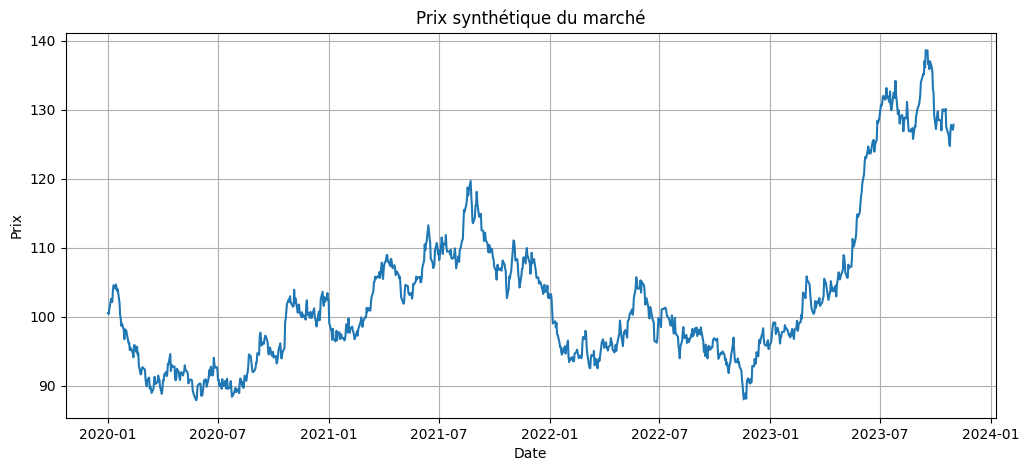

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(price.index, price.values)
plt.title("Prix synthétique du marché")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

## 2. Créer un univers de règles candidates

On simule maintenant $N$ règles.

Chaque règle produit un signal :

- $+1$ pour être long ;
- $-1$ pour être short ;
- $0$ pour être flat.

Dans cette première simulation, les règles sont majoritairement du bruit.

Elles ne possèdent pas de véritable pouvoir prédictif.

C'est volontaire : on veut voir jusqu'où le hasard peut aller quand on teste beaucoup de règles.

In [4]:
n_rules = 200

signals = np.random.choice(
    [-1, 0, 1],
    size=(n_days, n_rules),
    p=[0.35, 0.30, 0.35]
)

signals = pd.DataFrame(
    signals,
    index=dates,
    columns=[f"rule_{i:03d}" for i in range(n_rules)]
)

signals.head()

,rule_000,rule_001,rule_002,rule_003,rule_004,rule_005,rule_006,rule_007,rule_008,rule_009,...,rule_190,rule_191,rule_192,rule_193,rule_194,rule_195,rule_196,rule_197,rule_198,rule_199
2020-01-01,-1,-1,0,1,-1,1,-1,0,1,1,...,0,1,0,0,-1,0,-1,-1,0,1
2020-01-02,0,0,0,1,0,0,-1,-1,0,0,...,1,0,0,1,-1,0,0,-1,0,-1
2020-01-03,-1,-1,1,0,1,0,-1,0,0,-1,...,-1,-1,1,1,-1,0,1,-1,0,1
2020-01-06,0,-1,0,1,0,-1,1,-1,1,-1,...,-1,1,1,0,1,1,-1,0,-1,1
2020-01-07,0,0,1,0,1,0,-1,1,1,-1,...,1,-1,0,-1,0,-1,-1,0,-1,-1


## 3. Calculer les performances observées

La performance observée correspond au backtest original.

Pour éviter le look-ahead bias, on décale les signaux d'une période :

$$
r_{i,t}^{\text{rule}} = s_{i,t-1} \times r_t^{\text{market}}
$$

Ensuite, on calcule la moyenne annualisée de chaque règle.

Ici, on utilise $252$ jours de bourse par an.

In [5]:
def compute_rule_returns(signals_df: pd.DataFrame, market_ret: pd.Series) -> pd.DataFrame:
    """
    Calcule les rendements des règles.

    Les signaux sont décalés d'une période pour éviter le look-ahead bias.
    """
    shifted_signals = signals_df.shift(1).fillna(0)
    rule_returns = shifted_signals.mul(market_ret, axis=0)
    return rule_returns


def annualized_mean_return(rule_returns: pd.DataFrame, periods_per_year: int = 252) -> pd.Series:
    """
    Rendement moyen annualisé de chaque règle.
    """
    return rule_returns.mean(axis=0) * periods_per_year


observed_rule_returns = compute_rule_returns(signals, market)
observed_perf = annualized_mean_return(observed_rule_returns)

best_rule = observed_perf.idxmax()
best_observed_perf = observed_perf.max()

best_rule, best_observed_perf

('rule_087', np.float64(0.15851055679293116))

In [6]:
summary = pd.DataFrame({
    "annualized_mean_return": observed_perf
}).sort_values("annualized_mean_return", ascending=False)

summary.head(10)

,annualized_mean_return
rule_087,0.158511
rule_135,0.154293
rule_073,0.153233
rule_199,0.120661
rule_017,0.117174
rule_099,0.115284
rule_088,0.112720
rule_002,0.112030
rule_054,0.110708
rule_001,0.106497


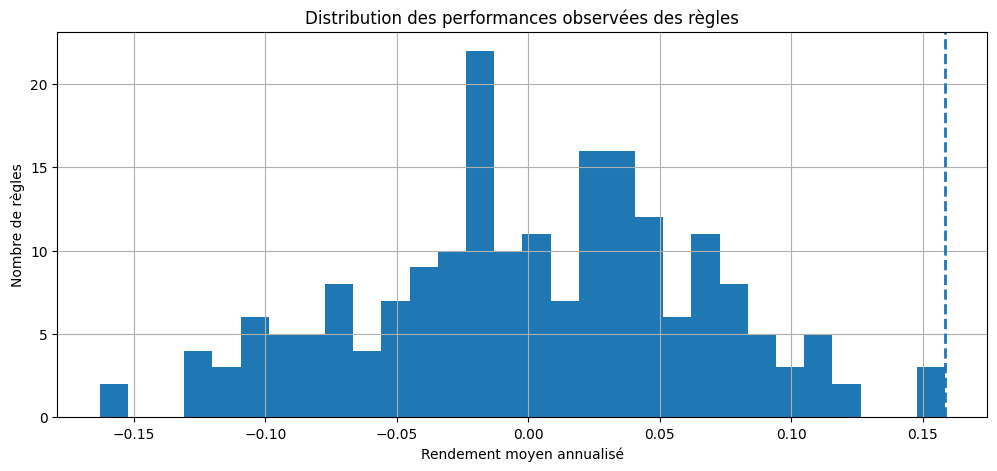

In [7]:
plt.figure(figsize=(12, 5))
plt.hist(observed_perf.values, bins=30)
plt.axvline(best_observed_perf, linestyle="--", linewidth=2)
plt.title("Distribution des performances observées des règles")
plt.xlabel("Rendement moyen annualisé")
plt.ylabel("Nombre de règles")
plt.grid(True)
plt.show()

## Lecture intermédiaire

Le meilleur candidat peut sembler intéressant.

Mais la question EBTA n'est pas :

> “La meilleure règle a-t-elle gagné dans le backtest ?”

La vraie question est :

> “La meilleure règle a-t-elle gagné davantage que ce que le meilleur hasard pouvait produire dans le même processus de recherche ?”

C'est ici que la MCPM intervient.

## 4. Implémenter la MCPM

Le protocole est le suivant :

1. On garde les signaux réels de toutes les règles.
2. On mélange les rendements du marché **sans remise**.
3. On recalcule les rendements de toutes les règles avec ce marché mélangé.
4. On calcule la performance moyenne annualisée de toutes les règles.
5. On conserve seulement la meilleure performance de la permutation.
6. On répète l'opération plusieurs milliers de fois.

Point essentiel :

> On utilise le même mélange de rendements pour toutes les règles à chaque itération.

Cela permet de préserver la structure de comparaison entre les règles.

In [8]:
def mcpm_max_distribution(
    signals_df: pd.DataFrame,
    market_ret: pd.Series,
    n_permutations: int = 2_000,
    periods_per_year: int = 252,
    seed: int = 123
) -> np.ndarray:
    """
    Construit la distribution MCPM du maximum.

    Pour chaque permutation :
    - les rendements du marché sont mélangés sans remise ;
    - toutes les règles sont évaluées sur le même mélange ;
    - on conserve uniquement la meilleure performance.
    """
    rng = np.random.default_rng(seed)
    shifted_signals = signals_df.shift(1).fillna(0).to_numpy()
    market_values = market_ret.to_numpy()

    max_performances = np.empty(n_permutations)

    for b in range(n_permutations):
        permuted_market = rng.permutation(market_values)
        permuted_rule_returns = shifted_signals * permuted_market[:, None]
        permuted_perf = permuted_rule_returns.mean(axis=0) * periods_per_year
        max_performances[b] = permuted_perf.max()

    return max_performances


mcpm_max = mcpm_max_distribution(
    signals_df=signals,
    market_ret=market,
    n_permutations=2_000,
    seed=777
)

mcpm_max[:10]

array([0.2071698 , 0.17361294, 0.16921149, 0.17311742, 0.17748228,
       0.16645184, 0.15382294, 0.16142783, 0.17882874, 0.20265105])

## 5. Calculer la p-value MCPM

La p-value MCPM répond à la question :

> Dans combien de permutations le meilleur champion du bruit fait-il aussi bien ou mieux que ma meilleure règle observée ?

Mathématiquement :

$$
p = \frac{1 + \sum_{b=1}^{B} \mathbf{1}\left(M_b^{\text{MCPM}} \geq M^{\text{observé}}\right)}{B + 1}
$$

On ajoute $1$ au numérateur et au dénominateur pour éviter une p-value exactement égale à zéro avec un nombre fini de simulations.

In [9]:
def permutation_p_value(observed_max: float, permuted_max_distribution: np.ndarray) -> float:
    """
    P-value de permutation avec correction de comptage fini.
    """
    b = len(permuted_max_distribution)
    exceedances = np.sum(permuted_max_distribution >= observed_max)
    return (1 + exceedances) / (b + 1)


p_value = permutation_p_value(best_observed_perf, mcpm_max)

p_value

np.float64(0.7741129435282359)

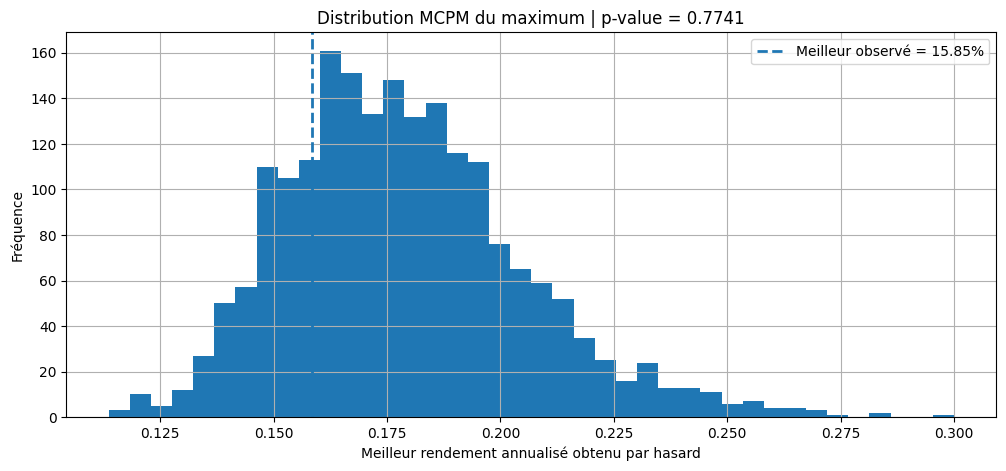

In [10]:
plt.figure(figsize=(12, 5))
plt.hist(mcpm_max, bins=40)
plt.axvline(best_observed_perf, linestyle="--", linewidth=2, label=f"Meilleur observé = {best_observed_perf:.2%}")
plt.title(f"Distribution MCPM du maximum | p-value = {p_value:.4f}")
plt.xlabel("Meilleur rendement annualisé obtenu par hasard")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()

## 6. Interprétation EBTA

La règle de lecture est directe :

| p-value MCPM | Interprétation |
|---:|---|
| $p \leq 0.01$ | Résultat très difficile à expliquer par le hasard |
| $0.01 < p \leq 0.05$ | Résultat statistiquement intéressant |
| $0.05 < p \leq 0.10$ | Zone grise |
| $p > 0.10$ | Le meilleur backtest ressemble fortement à un artefact de minage |

Attention :

Une p-value faible ne prouve pas que la stratégie gagnera dans le futur.

Elle indique seulement que la performance observée est difficile à obtenir sous l'hypothèse :

$$
H_0 : \text{les signaux n'ont aucun pouvoir prédictif}
$$

## 7. Exemple avec une vraie règle injectée

Maintenant, ajoutons volontairement une règle qui possède un petit avantage.

Pour rendre l'exemple visible, on crée une règle qui anticipe légèrement le signe du rendement suivant.

En pratique, cette situation représente une stratégie qui a un vrai signal, même faible.

In [11]:
signals_with_edge = signals.copy()

future_direction = np.sign(market.shift(-1)).fillna(0)

rng = np.random.default_rng(2026)
is_correct = rng.random(n_days) < 0.56

noise_direction = rng.choice([-1, 1], size=n_days)
edge_signal = np.where(is_correct, future_direction, -future_direction)
edge_signal = np.where(future_direction == 0, noise_direction, edge_signal)

signals_with_edge["edge_rule"] = edge_signal

observed_returns_edge = compute_rule_returns(signals_with_edge, market)
observed_perf_edge = annualized_mean_return(observed_returns_edge)

best_rule_edge = observed_perf_edge.idxmax()
best_observed_perf_edge = observed_perf_edge.max()

best_rule_edge, best_observed_perf_edge

('rule_087', np.float64(0.15851055679293097))

In [12]:
mcpm_max_edge = mcpm_max_distribution(
    signals_df=signals_with_edge,
    market_ret=market,
    n_permutations=2_000,
    seed=888
)

p_value_edge = permutation_p_value(best_observed_perf_edge, mcpm_max_edge)

p_value_edge

np.float64(0.7886056971514243)

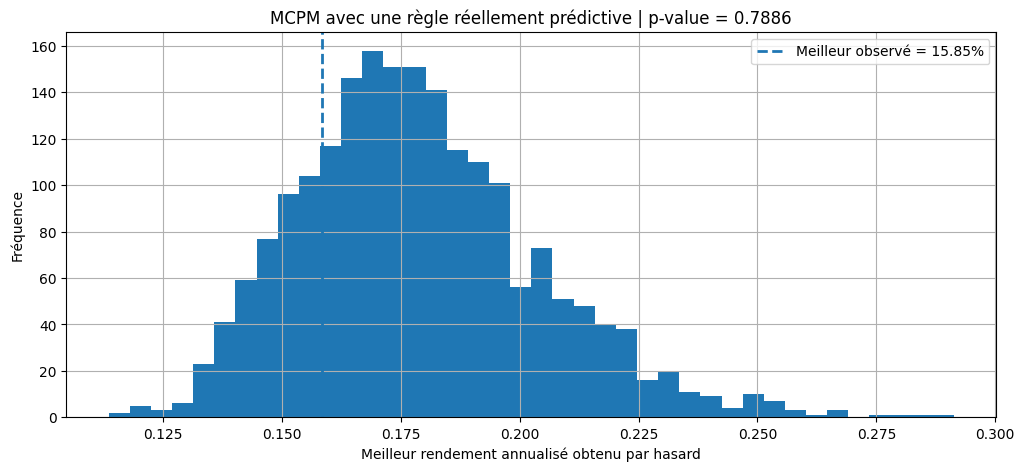

In [13]:
plt.figure(figsize=(12, 5))
plt.hist(mcpm_max_edge, bins=40)
plt.axvline(best_observed_perf_edge, linestyle="--", linewidth=2, label=f"Meilleur observé = {best_observed_perf_edge:.2%}")
plt.title(f"MCPM avec une règle réellement prédictive | p-value = {p_value_edge:.4f}")
plt.xlabel("Meilleur rendement annualisé obtenu par hasard")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()

## 8. Ce que la MCPM exige dans ton pipeline de backtest

Pour appliquer correctement la MCPM sur tes propres stratégies, tu dois sauvegarder plus que la performance finale.

Tu dois conserver :

| Élément à sauvegarder | Pourquoi c'est nécessaire |
|---|---|
| **Rendements bruts du marché** | Base à permuter |
| **Signaux de chaque règle** | Permet de recoupler signaux et rendements mélangés |
| **Identifiant de chaque règle** | Permet de retrouver le candidat sélectionné |
| **Même historique temporel pour toutes les règles** | Évite les comparaisons incohérentes |
| **Coûts de transaction réalistes** | Évite de valider une illusion non tradable |

En trading algorithmique, la MCPM devient donc un module de validation placé après la phase de recherche.

Elle ne remplace pas :

- le **walk-forward testing** ;
- l'analyse des coûts ;
- l'analyse de robustesse ;
- la validation hors marché ou hors régime ;
- l'analyse du risque d'exécution.

Mais elle attaque un problème précis :

> Le meilleur candidat est-il meilleur que le meilleur hasard issu du même processus de minage ?

## 9. Version fonctionnelle réutilisable

La cellule suivante regroupe le protocole MCPM en une seule fonction.

Tu peux la réutiliser dans ton pipeline EBTA.

In [14]:
def run_mcpm_test(
    signals_df: pd.DataFrame,
    market_ret: pd.Series,
    n_permutations: int = 5_000,
    periods_per_year: int = 252,
    seed: int = 42
) -> dict:
    """
    Exécute un test MCPM complet.

    Returns
    -------
    dict
        Résultats principaux :
        - best_rule
        - observed_max
        - p_value
        - mcpm_distribution
        - observed_performances
    """
    observed_rule_returns = compute_rule_returns(signals_df, market_ret)
    observed_performances = annualized_mean_return(
        observed_rule_returns,
        periods_per_year=periods_per_year
    )

    best_rule = observed_performances.idxmax()
    observed_max = observed_performances.max()

    mcpm_distribution = mcpm_max_distribution(
        signals_df=signals_df,
        market_ret=market_ret,
        n_permutations=n_permutations,
        periods_per_year=periods_per_year,
        seed=seed
    )

    p_value = permutation_p_value(observed_max, mcpm_distribution)

    return {
        "best_rule": best_rule,
        "observed_max": observed_max,
        "p_value": p_value,
        "mcpm_distribution": mcpm_distribution,
        "observed_performances": observed_performances
    }


result = run_mcpm_test(
    signals_df=signals_with_edge,
    market_ret=market,
    n_permutations=2_000,
    seed=999
)

result["best_rule"], result["observed_max"], result["p_value"]

('rule_087', np.float64(0.15851055679293097), np.float64(0.7876061969015492))

## 10. Erreurs fréquentes

### Erreur 1 : permuter les signaux au lieu des rendements

On peut le faire dans certains cadres, mais la formulation présentée ici consiste à mélanger les **rendements du marché** et à garder les signaux fixes.

L'objectif est de demander :

> Mes signaux réels restent-ils bons quand on détruit leur alignement avec les vrais jours de marché ?

### Erreur 2 : utiliser un mélange différent pour chaque règle

Cela casse la cohérence de comparaison entre règles.

Dans un univers de recherche, toutes les règles doivent être testées sur le **même marché permuté** à chaque itération.

### Erreur 3 : regarder la distribution d'une seule règle

La MCPM appliquée au data mining doit regarder la distribution du **maximum**.

Sinon, tu ignores le fait que tu as sélectionné le meilleur candidat parmi beaucoup de règles.

### Erreur 4 : oublier les coûts de transaction

Une règle peut être statistiquement significative mais non tradable.

Après la MCPM, il faut encore vérifier :

- spread ;
- commissions ;
- slippage ;
- latence ;
- capacité ;
- stabilité par régime de marché.

## Eurêka final

> La MCPM ne teste pas seulement une stratégie.  
> Elle teste le **processus de sélection** qui a produit cette stratégie.

C'est la nuance décisive.

Quand tu mines un grand univers de règles, le vrai adversaire n'est pas seulement le marché.

Le vrai adversaire est le **meilleur résultat que le hasard peut produire après des centaines ou milliers de tentatives**.

La MCPM te force donc à comparer ton champion réel au **champion du bruit**.

Si ton champion ne bat pas le champion du bruit, alors ton backtest est probablement du **métal des fous**.

S'il le bat nettement, tu n'as pas encore prouvé que tu possèdes une machine à cash, mais tu as franchi une barrière statistique essentielle.

## Annexe — Texte source collé


### **THE MONTE CARLO PERMUTATION METHOD (MCPM)**

La méthode de permutation de Monte Carlo (MCPM) est présentée par David Aronson comme une alternative robuste au *White's Reality Check* (WRC) pour évaluer la significativité statistique des règles découvertes par minage de données. Elle permet de déterminer si le profit du meilleur candidat est le fruit du talent ou d'un simple alignement accidentel avec les fluctuations du marché.

#### **(AJOUT) Idées clés :**
*   **Alternative au WRC :** Une méthode de randomization pour tester la validité d'un univers de règles sans sacrifier de données historiques.
*   **Appariement Aléatoire :** Les signaux de la règle (+1/-1) sont couplés aléatoirement avec les rendements du marché pour détruire tout pouvoir prédictif.
*   **Échantillonnage sans remise :** Contrairement au bootstrapping, la MCPM utilise les rendements réels du marché en les "mélangeant" simplement.
*   **Préservation des corrélations :** La méthode utilise le même mélange de données pour toutes les règles testées afin de respecter la structure de corrélation de l'univers de recherche.
*   **Distribution du Maximum :** Comme le WRC, elle construit une distribution basée sur le rendement maximal obtenu par le hasard parmi $N$ règles.

#### **Référence :**
*The Monte Carlo Permutation Method*, Chapitre 6, pages 327 à 328 (ainsi que les détails techniques en pages 238-243).

#### **Citation Directe :**
« To simulate the performance of a rule devoid of predictive power, MC randomly pairs rule output values with daily market price changes. [...] The return earned by the random pairings becomes the benchmark against which the actual rule returns are compared. » (Page 327).

#### **Vision Macro :**
L'enjeu est de valider le processus de sélection lui-même. Aronson explique que dans un marché hautement aléatoire, tester des milliers de règles finit par produire un "gagnant" par pur accident. La MCPM agit comme un simulateur de "bruit" : elle répond à la question : « Quel score obtiendrait le meilleur des menteurs si on mélangeait l'ordre des jours de bourse ? ». Si votre stratégie réelle ne surpasse pas significativement ce "champion du bruit", alors votre performance n'est qu'un artefact statistique sans valeur future.

#### **Vision Micro :**
Le mécanisme technique de la MCPM pour le minage de données suit un protocole rigoureux :

1. **Données requises :** Contrairement au WRC qui utilise l'historique des rendements des règles, la MCPM nécessite la série temporelle des signaux (+1 pour long, -1 pour short) et la série des rendements bruts du marché.
2. **La Permutation (Scrambling) :** On prend l'historique des rendements du marché et on le mélange aléatoirement. Chaque rendement journalier est réassigné à une date au hasard.
3. **L'Appariement :** On multiplie les signaux réels de la règle par cette version "mélangée" du marché. Cela crée une "règle de bruit" qui n'a aucun pouvoir prédictif puisque le lien temporel entre le signal et le prix est rompu.
4. **Calcul du Maximum :** Pour chaque permutation, on calcule le rendement moyen de *toutes* les $N$ règles de l'univers et on ne conserve que le **rendement maximal**.
5. **Répétition :** On répète l'opération des milliers de fois pour créer la distribution d'échantillonnage du maximum.
6. **P-Value :** On regarde combien de fois ces "records de chance" égalent ou dépassent la performance observée de votre stratégie.

#### **Résumé Simplifié :**
Imaginez un jeu de cartes où chaque carte est un jour de bourse. Votre stratégie dit "Parier" ou "Ne pas parier" sur chaque jour. La MCPM mélange les cartes et les redistribue. Si votre stratégie gagne toujours avec des cartes mélangées, c'est qu'elle n'a pas de talent réel ; elle a juste eu de la chance lors de la première distribution. L'ordinateur répète ce mélange 5 000 fois pour voir quel est le plus gros gain qu'un joueur chanceux peut obtenir.

#### **Actions Concrètes :**
* **Sauvegarder les signaux (+1/-1) :** Pour appliquer la MCPM, vous devez conserver l'historique des positions de chaque règle testée, pas seulement le résultat final.
* **Utiliser le même "mélange" pour tout l'univers :** Lors de la simulation, veillez à ce que le rendement du jour X soit apparié au même jour Y pour toutes les règles concurrentes afin de maintenir la cohérence statistique.
* **Appliquer l'amélioration Romano-Wolf :** Pour réduire le risque de rater une règle réellement performante (Erreur de Type II), utilisez la version améliorée de la méthode mentionnée par Aronson.
* **Ne pas chercher d'intervalles de confiance :** Notez que, contrairement au WRC, la MCPM ne permet pas de générer d'intervalles de confiance pour le rendement moyen.

#### **À retenir absolument :**
* La MCPM est un **test de bruit** pour le minage de données.
* Elle mélange les jours de bourse pour **détruire tout lien logique** entre signaux et prix.
* Elle identifie le **record de profit** que le hasard peut générer parmi $N$ règles.
* Si la p-value est élevée (ex: > 0.05), le profit du backtest est du **"métal des fous"**.
* C'est l'outil indispensable pour valider des recherches **intensives et complexes**.